In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pycocotools.coco import COCO
import os
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from keras.models import Model
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, concatenate, Input
from tensorflow.keras.models import Model

Total number of image files in /content/drive/MyDrive/archive/test: 215
Total number of image files in /content/drive/MyDrive/archive/train: 1502
Total number of image files in /content/drive/MyDrive/archive/valid: 429


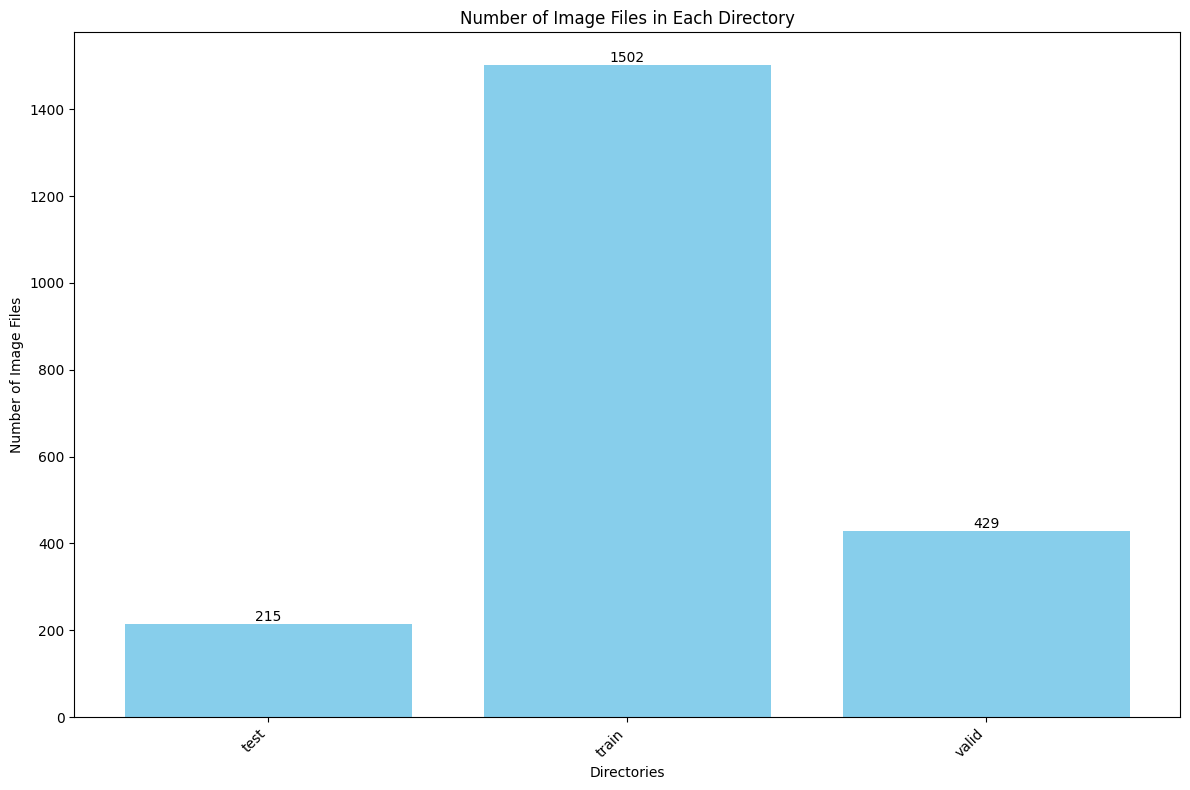

In [ ]:


# Function to count image files in a directory
def count_image_files(directory):
    # Supported image extensions
    image_extensions = ['.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff']

    # Dictionary to store count of each type
    image_count = {ext: 0 for ext in image_extensions}
    total_images = 0

    # Walk through directory
    for root, dirs, files in os.walk(directory):
        for file in files:
            # Get file extension
            ext = os.path.splitext(file)[1].lower()
            if ext in image_extensions:
                image_count[ext] += 1
                total_images += 1

    return total_images

# Function to plot the image counts
def plot_image_counts(image_counts, directory_names):
    plt.figure(figsize=(12, 8))
    bars = plt.bar(directory_names, image_counts, color='skyblue')
    plt.xlabel('Directories')
    plt.ylabel('Number of Image Files')
    plt.title('Number of Image Files in Each Directory')
    plt.xticks(rotation=45, ha='right')
    # Add counts above the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# List of directories to check
directories = [
    '/content/drive/MyDrive/archive/test',
    '/content/drive/MyDrive/archive/train',
    '/content/drive/MyDrive/archive/valid'
    # Add more directories as needed
]

# Get directory names from paths
directory_names = [os.path.basename(directory) for directory in directories]

# Count image files in each directory
image_counts = []
for directory in directories:
    image_count = count_image_files(directory)
    image_counts.append(image_count)
    print(f"Total number of image files in {directory}: {image_count}")

# Plot the results
plot_image_counts(image_counts, directory_names)


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


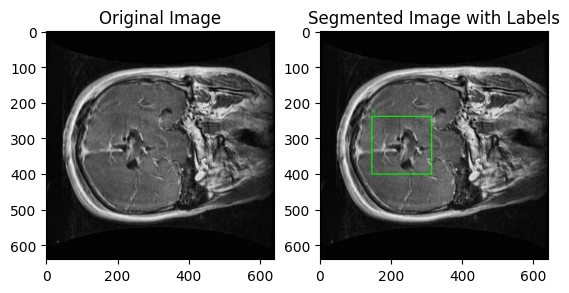

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


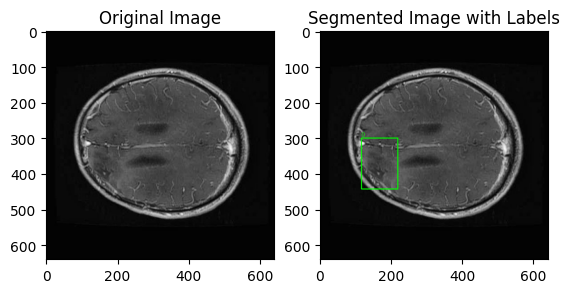

In [ ]:
def plot_images(annotations_file, images_folder):
# Initialize COCO API for instance annotations
  coco = COCO(annotations_file)
  # Get a list of image IDs
  image_ids = coco.getImgIds()
  # Define the number of images to display
  num_images_to_display = 1
  segmented_images = []
  for i in range(num_images_to_display):
    # Choose an image ID
    image_id = image_ids[i]
    # Load image and annotations
    image_info = coco.loadImgs(image_id)[0]
    image_path = os.path.join(images_folder,
    image_info['file_name'])
    image = cv2.imread(image_path)
    annotations_ids = coco.getAnnIds(imgIds=image_info['id'])
    annotations = coco.loadAnns(annotations_ids)
    # Create a binary mask for each annotation
    segmentation_masks = [coco.annToMask(ann) for ann in annotations]
    # Plot the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f'Original Image')
    #plt.subplot(1, 3, 2)
    masked_image = image.copy()
    for mask1 in segmentation_masks:
     # masked_image[mask1 == 1] = [0, 255, 0] # Green color for segmented regions

      #plt.imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
      #plt.title(f'Masked Image')
      #segmented_image = image.copy()
      # Plot the segmented image with labels
      plt.subplot(1, 3, 2)
      segmented_image1 = image.copy()
      for mask, ann in zip(segmentation_masks, annotations):
        color = (0, 255, 0) # Green color for segmentation
        segmented_image1 = cv2.addWeighted(segmented_image1, 1, cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR), 0.5, 0)
        x, y, w, h = map(int, ann['bbox'])
        cv2.rectangle(segmented_image1, (x, y), (x + w, y + h), color, 2)
        cv2.putText(segmented_image1, coco.loadCats(ann['category_id'])[0]['name'], (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
        plt.imshow(cv2.cvtColor(segmented_image1, cv2.COLOR_BGR2RGB))
        plt.title(f'Segmented Image with Labels')
        plt.show()
# Define file paths
train_annotations_file = '/content/drive/MyDrive/archive/train/_annotations.coco.json'
train_images_folder = '/content/drive/MyDrive/archive/train'
val_images_folder = '/content/drive/MyDrive/archive/valid'
val_annotations_file = '/content/drive/MyDrive/archive/valid/_annotations.coco.json'
test_image_folder = '/content/drive/MyDrive/archive/test'
test_annotations_file = '/content/drive/MyDrive/archive/test/_annotations.coco.json'
plot_images(train_annotations_file, train_images_folder)
plot_images(val_annotations_file, val_images_folder)

In [ ]:
import os
import numpy as np
import cv2
import json
from pycocotools.coco import COCO
from skimage.draw import polygon
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set paths
train_image_dir = '/content/drive/MyDrive/archive/train'
train_mask_path = '/content/drive/MyDrive/archive/train/_annotations.coco.json'
val_image_dir = '/content/drive/MyDrive/archive/valid'
val_mask_path = '/content/drive/MyDrive/archive/valid/_annotations.coco.json'
test_image_dir = '/content/drive/MyDrive/archive/test'
test_mask_path = '/content/drive/MyDrive/archive/test/_annotations.coco.json'

# Parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 3

def create_mask_from_annotations(annotations, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    for annotation in annotations:
        segmentation = annotation['segmentation'][0]
        poly = np.array(segmentation).reshape((len(segmentation) // 2, 2))
        rr, cc = polygon(poly[:, 1], poly[:, 0], (height, width))
        mask[rr, cc] = 1
    return mask

def load_images_and_masks(image_dir, mask_path, img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    coco = COCO(mask_path)
    images = []
    masks = []

    for img_id in coco.getImgIds():
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(image_dir, img_info['file_name'])

        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Unable to read image at {img_path}")
            continue
        img = cv2.resize(img, (img_width, img_height))
        img = img / 255.0

        ann_ids = coco.getAnnIds(imgIds=img_id)
        annotations = coco.loadAnns(ann_ids)

        mask = create_mask_from_annotations(annotations, img_info['height'], img_info['width'])
        mask = cv2.resize(mask, (img_width, img_height))
        mask = mask / 255.0

        images.append(img)
        masks.append(mask)

    images = np.array(images)
    masks = np.array(masks)
    masks = np.expand_dims(masks, axis=-1)  # Add channel dimension

    return images, masks

# Load datasets
train_images, train_masks = load_images_and_masks(train_image_dir, train_mask_path)
val_images, val_masks = load_images_and_masks(val_image_dir, val_mask_path)
test_images, test_masks = load_images_and_masks(test_image_dir, test_mask_path)

print(f"Train images shape: {train_images.shape}")
print(f"Train masks shape: {train_masks.shape}")
print(f"Validation images shape: {val_images.shape}")
print(f"Validation masks shape: {val_masks.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test masks shape: {test_masks.shape}")


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Train images shape: (1502, 128, 128, 3)
Train masks shape: (1502, 128, 128, 1)
Validation images shape: (429, 128, 128, 3)
Validation masks shape: (429, 128, 128, 1)
Test images shape: (215, 128, 128, 3)
Test masks shape: (215, 128, 128, 1)


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model

def unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D((2, 2))(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D((2, 2))(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = unet_model()
model.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11            │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_209 (Conv2D)       │ (None, 128, 128, 64)   │          1,792 │ input_layer_11[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_210 (Conv2D)       │ (None, 128, 128, 64)   │         36,928 │ conv2d_209[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_44          │ (None, 64, 64, 64)     │              0 │ conv2d_210[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_211 (Conv2D)       │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d_44[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_212 (Conv2D)       │ (None, 64, 64, 128)    │        147,584 │ conv2d_211[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_45          │ (None, 32, 32, 128)    │              0 │ conv2d_212[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_213 (Conv2D)       │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_45[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_214 (Conv2D)       │ (None, 32, 32, 256)    │        590,080 │ conv2d_213[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_46          │ (None, 16, 16, 256)    │              0 │ conv2d_214[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_215 (Conv2D)       │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_46[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_216 (Conv2D)       │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_215[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_47          │ (None, 8, 8, 512)      │              0 │ conv2d_216[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_217 (Conv2D)       │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_47[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_218 (Conv2D)       │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_217[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_44          │ (None, 16, 16, 1024)   │              0 │ conv2d_218[0][0]       │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_44       

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def create_dataset(images, masks, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((images, masks))
    dataset = dataset.shuffle(buffer_size=len(images))
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return dataset

# Create datasets
train_dataset = create_dataset(train_images, train_masks)
val_dataset = create_dataset(val_images, val_masks)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25
)


Epoch 1/25


ValueError: 'U-Net model_conv2d_209_kernel_momentum' is not a valid scope name. A scope name has to match the following pattern: ^[A-Za-z0-9_.\\/>-]*$

In [ ]:
# Evaluate on the test set
model.evaluate(test_images, test_masks)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to display images
def display_images(images, titles=None, cmap=None):
    n = len(images)
    plt.figure(figsize=(20, 10))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmap)
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Predict masks on the test set
predicted_masks = model.predict(test_images)

# Threshold the predicted masks
#predicted_masks = (predicted_masks > 0.5).astype(np.uint8)

# Display some test images with their true and predicted masks
num_images_to_display = 5
indices = np.random.choice(len(test_images), num_images_to_display, replace=False)

for i in indices:
    test_img = test_images[i]
    true_mask = test_masks[i].squeeze()
    predicted_mask = predicted_masks[i].squeeze()

    display_images(
        [test_img, true_mask, predicted_mask],
        titles=['Test Image', 'True Mask', 'Predicted Mask'],
        cmap='gray'
    )


In [ ]:
import matplotlib.pyplot as plt

# Plot model loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot model accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
